In [32]:
import os
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split, KFold
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
import json

In [33]:
stage = "river"

### Reading and compacting dfs

In [34]:
compact = False

In [35]:
# Iterate over files in dfs/*.parquet and combine to one df
dfs = []

read = []
for file in os.listdir('dfs'):
    if file.endswith('.parquet'):
        read.append(file)
        df = pd.read_parquet(f"dfs/{file}")
        dfs.append(df)
    if file.endswith('.csv'):
        read.append(file)
        df = pd.read_csv(f"dfs/{file}", index_col=0)
        dfs.append(df)

raw_df = pd.concat(dfs, ignore_index=True)

if compact and len(dfs) > 0:
    print("Compacintg dfs")
    # Move read files to trash and write combined df to dfs/combined_{timestamp}.parquet
    trash = 'dfs/trash'
    for f in read:
        os.rename(f'dfs/{f}', f'{trash}/{f}')

    timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
    raw_df.to_parquet(f'dfs/compacted_{timestamp}.parquet')

dfs = [] # Clear memory
raw_df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size,stage
0,0.000419,0.000340,0.000317,0.001056,0.000920,0.000251,0.000839,0.000523,0.001255,0.000643,...,0,411,6,417,True,False,True,828,1396,river
1,0.000949,0.001175,0.000867,0.001118,0.000547,0.000335,0.000376,0.000019,0.000609,0.000970,...,0,224,65,289,True,False,True,513,1496,river
2,0.000953,0.000382,0.001230,0.000696,0.000345,0.000526,0.000573,0.000548,0.000306,0.001121,...,0,216,47,263,True,False,True,479,1431,river
3,0.000599,0.000679,0.000011,0.001274,0.000049,0.000294,0.001106,0.000297,0.000436,0.000799,...,0,406,151,557,True,False,True,963,1930,river
4,0.000326,0.000179,0.000722,0.000766,0.000419,0.000994,0.000819,0.001090,0.000313,0.000129,...,0,389,77,466,True,False,True,855,2236,river
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3451,0.000606,0.000134,0.000044,0.001506,0.000911,0.000148,0.000991,0.001004,0.001256,0.001168,...,108,226,198,316,True,True,True,542,2083,river
3452,0.001264,0.000755,0.000916,0.000563,0.000142,0.000096,0.000540,0.001188,0.001201,0.000580,...,0,384,189,573,True,False,True,957,2419,river
3453,0.000171,0.000525,0.000313,0.001181,0.000674,0.000659,0.001246,0.000157,0.000905,0.000312,...,253,635,515,897,True,True,True,1532,2894,river
3454,0.000262,0.000291,0.000953,0.001247,0.000777,0.000546,0.001030,0.001214,0.001298,0.000451,...,0,280,0,280,True,False,False,560,2284,river


In [36]:
df = raw_df[raw_df["stage"] == stage]
df = df.drop(columns=["stage"])
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size
0,0.000419,0.000340,0.000317,0.001056,0.000920,0.000251,0.000839,0.000523,0.001255,0.000643,...,0.0,0,411,6,417,True,False,True,828,1396
1,0.000949,0.001175,0.000867,0.001118,0.000547,0.000335,0.000376,0.000019,0.000609,0.000970,...,0.0,0,224,65,289,True,False,True,513,1496
2,0.000953,0.000382,0.001230,0.000696,0.000345,0.000526,0.000573,0.000548,0.000306,0.001121,...,0.0,0,216,47,263,True,False,True,479,1431
3,0.000599,0.000679,0.000011,0.001274,0.000049,0.000294,0.001106,0.000297,0.000436,0.000799,...,0.0,0,406,151,557,True,False,True,963,1930
4,0.000326,0.000179,0.000722,0.000766,0.000419,0.000994,0.000819,0.001090,0.000313,0.000129,...,0.0,0,389,77,466,True,False,True,855,2236
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3451,0.000606,0.000134,0.000044,0.001506,0.000911,0.000148,0.000991,0.001004,0.001256,0.001168,...,0.0,108,226,198,316,True,True,True,542,2083
3452,0.001264,0.000755,0.000916,0.000563,0.000142,0.000096,0.000540,0.001188,0.001201,0.000580,...,0.0,0,384,189,573,True,False,True,957,2419
3453,0.000171,0.000525,0.000313,0.001181,0.000674,0.000659,0.001246,0.000157,0.000905,0.000312,...,0.0,253,635,515,897,True,True,True,1532,2894
3454,0.000262,0.000291,0.000953,0.001247,0.000777,0.000546,0.001030,0.001214,0.001298,0.000451,...,0.0,0,280,0,280,True,False,False,560,2284


In [37]:
# Show all types of columns:
list(sorted(set(["_".join(col.split("_")[0:2]) for col in df.columns])))

['game_size',
 'opponent_bet',
 'opponent_has',
 'player_bet',
 'player_has',
 'player_turn',
 'pot',
 'prob_O',
 'prob_P',
 'public_card',
 'value_of']

### Preprocessing

In [38]:
# Divide all bets by game_size
bet_columns = [
    "player_bet_in_stage",
    "player_bet_in_game",
    "opponent_bet_in_stage",
    "opponent_bet_in_game",
    "pot",
]

def scale_bets(df):
    df[bet_columns] = df[bet_columns].div(df["game_size"], axis=0)
    return df


scale_bets(df)
df[bet_columns]

,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,pot
0,0.000000,0.294413,0.004298,0.298711,0.593123
1,0.000000,0.149733,0.043449,0.193182,0.342914
2,0.000000,0.150943,0.032844,0.183788,0.334731
3,0.000000,0.210363,0.078238,0.288601,0.498964
4,0.000000,0.173971,0.034436,0.208408,0.382379
...,...,...,...,...,...
3451,0.051848,0.108497,0.095055,0.151704,0.260202
3452,0.000000,0.158743,0.078131,0.236875,0.395618
3453,0.087422,0.219419,0.177954,0.309952,0.529371
3454,0.000000,0.122592,0.000000,0.122592,0.245184


In [39]:
# Scale range features so that the mean becomes 0 and the standard deviation becomes 1
range_columns = [col for col in df.columns if col.startswith("prob_")]
def scale_ranges(df, training_mean, training_sd):
    df[range_columns] = (df[range_columns] - training_mean) / training_sd
    return df

def get_training_range_mean_and_sd(df):
    return df[range_columns].to_numpy().mean(), df[range_columns].to_numpy().std()

def revert_range_scaling(df, training_mean, training_sd):
    df[range_columns] = df[range_columns] * training_sd + training_mean
    return df

mean_training_range_val, sd_training_range_val = get_training_range_mean_and_sd(df)
scale_ranges(df, mean_training_range_val, sd_training_range_val)
print("Original mean and sd of range features:")
print(mean_training_range_val, sd_training_range_val)
print("Mean and sd of range features after scaling:")
print(df[range_columns].to_numpy().mean(), df[range_columns].to_numpy().std())
df[range_columns]

Original mean and sd of range features:
0.0007541478129713198 0.00043539071519535733
Mean and sd of range features after scaling:
-1.1518819713678366e-15 1.0000000000000002


,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,prob_O_has_hand_1316,prob_O_has_hand_1317,prob_O_has_hand_1318,prob_O_has_hand_1319,prob_O_has_hand_1320,prob_O_has_hand_1321,prob_O_has_hand_1322,prob_O_has_hand_1323,prob_O_has_hand_1324,prob_O_has_hand_1325
0,-0.769312,-0.952185,-1.004120,0.692310,0.380736,-1.155900,0.194509,-0.531772,1.150819,-0.254342,...,0.320068,-1.320476,-0.512991,-0.451463,0.818867,0.208147,-0.234459,0.700231,-0.835202,-1.460855
1,0.446918,0.966486,0.259457,0.836705,-0.475765,-0.962554,-0.867840,-1.688433,-0.332320,0.495439,...,0.602183,0.586770,0.073470,-1.344483,-1.718703,0.247787,-1.279604,-1.582959,-0.437100,1.291309
2,0.456900,-0.855364,1.093043,-0.134404,-0.938799,-0.523358,-0.416194,-0.472367,-1.028713,0.843354,...,-0.318325,-0.479971,0.571218,1.748329,-0.621685,0.202869,-0.351977,1.504765,-0.922662,-1.300332
3,-0.357448,-0.172343,-1.706339,1.194397,-1.619746,-1.057276,0.808921,-1.049727,-0.730687,0.102773,...,-0.898421,1.103401,1.481212,-0.359877,0.553513,0.343191,0.902733,0.752007,0.110029,-1.637316
4,-0.983335,-1.321743,-0.074573,0.026492,-0.769263,0.551269,0.147967,0.772060,-1.013481,-1.435661,...,0.933804,-1.532676,-0.739075,0.233248,-0.371086,-1.612179,-0.295093,0.021550,1.280766,-0.660210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3451,-0.341025,-1.424308,-1.631079,1.726235,0.360463,-1.391824,0.544126,0.574604,1.152546,0.950768,...,-1.208683,0.760720,-0.054081,0.782765,1.295872,-0.249892,0.556880,-0.070781,1.245405,1.107138
3452,1.170772,0.002051,0.371365,-0.438238,-1.406118,-1.511757,-0.491399,0.996849,1.025607,-0.400082,...,-0.462981,0.254651,1.374757,-0.591649,-1.417917,0.967593,0.171000,-0.100374,-0.134046,-1.191574
3453,-1.338723,-0.526398,-1.013770,0.979244,-0.183461,-0.219231,1.129302,-1.372661,0.345462,-1.014724,...,-1.393269,0.266110,-0.996806,0.316525,0.245269,-0.481560,1.066764,-0.162673,-1.714348,-0.920114
3454,-1.130363,-1.063269,0.455734,1.131854,0.051789,-0.478055,0.633253,1.056404,1.249419,-0.695706,...,1.303955,0.980218,0.677769,0.864519,-0.527502,1.152571,1.265700,1.019492,1.526197,1.580038


In [40]:
# Make boolean features 0 or 1
bool_columns = [
    "player_turn",
    "player_has_bet",
    "opponent_has_bet",
]


def encode_bools(df):
    df[bool_columns] = df[bool_columns].astype(int)


encode_bools(df)
df[bool_columns]

,player_turn,player_has_bet,opponent_has_bet
0,1,0,1
1,1,0,1
2,1,0,1
3,1,0,1
4,1,0,1
...,...,...,...
3451,1,1,1
3452,1,0,1
3453,1,1,1
3454,1,0,0


In [41]:
# Drop game_size column
df = df.drop(columns=["game_size"])
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_50,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot
0,-0.769312,-0.952185,-1.004120,0.692310,0.380736,-1.155900,0.194509,-0.531772,1.150819,-0.254342,...,0.0,0.0,0.000000,0.294413,0.004298,0.298711,1,0,1,0.593123
1,0.446918,0.966486,0.259457,0.836705,-0.475765,-0.962554,-0.867840,-1.688433,-0.332320,0.495439,...,0.0,0.0,0.000000,0.149733,0.043449,0.193182,1,0,1,0.342914
2,0.456900,-0.855364,1.093043,-0.134404,-0.938799,-0.523358,-0.416194,-0.472367,-1.028713,0.843354,...,0.0,0.0,0.000000,0.150943,0.032844,0.183788,1,0,1,0.334731
3,-0.357448,-0.172343,-1.706339,1.194397,-1.619746,-1.057276,0.808921,-1.049727,-0.730687,0.102773,...,0.0,0.0,0.000000,0.210363,0.078238,0.288601,1,0,1,0.498964
4,-0.983335,-1.321743,-0.074573,0.026492,-0.769263,0.551269,0.147967,0.772060,-1.013481,-1.435661,...,0.0,0.0,0.000000,0.173971,0.034436,0.208408,1,0,1,0.382379
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3451,-0.341025,-1.424308,-1.631079,1.726235,0.360463,-1.391824,0.544126,0.574604,1.152546,0.950768,...,0.0,0.0,0.051848,0.108497,0.095055,0.151704,1,1,1,0.260202
3452,1.170772,0.002051,0.371365,-0.438238,-1.406118,-1.511757,-0.491399,0.996849,1.025607,-0.400082,...,0.0,0.0,0.000000,0.158743,0.078131,0.236875,1,0,1,0.395618
3453,-1.338723,-0.526398,-1.013770,0.979244,-0.183461,-0.219231,1.129302,-1.372661,0.345462,-1.014724,...,0.0,0.0,0.087422,0.219419,0.177954,0.309952,1,1,1,0.529371
3454,-1.130363,-1.063269,0.455734,1.131854,0.051789,-0.478055,0.633253,1.056404,1.249419,-0.695706,...,0.0,0.0,0.000000,0.122592,0.000000,0.122592,1,0,0,0.245184


### Data validation

In [42]:
value_columns = [col for col in df.columns if col.startswith("value_")]
print("Mean of target variable:", df[value_columns].to_numpy().mean())
print("SD of target variable:", df[value_columns].to_numpy().std())
print("Min of target variable:", df[value_columns].to_numpy().min())
print("Max of target variable:", df[value_columns].to_numpy().max())
df[value_columns]

Mean of target variable: -0.0030671447300403367
SD of target variable: 0.10280686496547259
Min of target variable: -0.7319337788526715
Max of target variable: 0.7272040571620371


,value_of_hand_0,value_of_hand_1,value_of_hand_2,value_of_hand_3,value_of_hand_4,value_of_hand_5,value_of_hand_6,value_of_hand_7,value_of_hand_8,value_of_hand_9,...,value_of_hand_1316,value_of_hand_1317,value_of_hand_1318,value_of_hand_1319,value_of_hand_1320,value_of_hand_1321,value_of_hand_1322,value_of_hand_1323,value_of_hand_1324,value_of_hand_1325
0,0.402363,-0.000874,0.351273,0.162303,0.093164,0.043620,-0.113727,0.017140,-0.036647,0.000000,...,-0.044108,-0.081637,-0.137985,-0.000721,-0.052274,-0.058197,-0.061619,-0.092792,-0.096674,-0.001061
1,-0.081638,-0.000498,-0.028550,-0.090864,0.070579,0.067363,0.060463,0.050083,0.000000,0.034855,...,-0.061026,0.024404,0.010037,0.001629,-0.062474,-0.065114,-0.067324,0.008741,0.000099,-0.002278
2,0.241291,-0.000329,0.202978,0.056633,0.032012,0.016464,0.005828,0.000817,-0.052290,-0.020656,...,0.000000,0.000000,-0.041838,-0.064753,0.000000,0.000000,0.000000,0.000000,0.000000,-0.047671
3,0.001929,0.379400,0.334204,-0.000464,-0.000783,-0.097363,-0.000641,0.000000,0.263324,0.077466,...,-0.000957,-0.000996,-0.000999,-0.017562,0.061099,0.032305,0.010830,0.025084,0.005923,0.005152
4,0.072178,0.000316,0.066442,-0.000460,0.059202,-0.010708,0.048682,0.032374,0.018234,0.005971,...,0.010835,0.002015,-0.045242,-0.066926,0.000951,-0.048285,-0.069988,-0.051346,-0.072479,-0.092398
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3451,-0.065529,-0.073302,0.000000,0.000000,-0.079839,-0.087219,0.000000,-0.094099,-0.101385,-0.109734,...,0.137327,0.116258,0.095871,-0.026285,0.114424,0.094035,-0.027785,0.089407,-0.029130,-0.029462
3452,0.019414,-0.000720,0.020095,0.019561,0.017655,-0.000759,-0.005162,-0.008029,0.015384,0.013418,...,-0.000522,-0.000502,-0.000530,-0.000580,-0.013092,0.047680,0.031739,0.046899,0.031036,0.027667
3453,0.345951,0.344209,-0.026936,0.312363,0.264424,-0.058003,0.204619,0.000000,0.134436,-0.133568,...,-0.111460,0.000000,-0.221216,-0.114253,0.000000,-0.186473,-0.236552,0.000000,0.000000,-0.191652
3454,-0.000602,-0.000032,-0.000031,-0.000032,-0.000032,-0.000033,-0.006720,-0.000734,-0.000820,-0.001093,...,-0.006043,-0.006186,-0.006406,-0.006517,-0.006129,-0.006348,-0.006460,-0.006431,-0.006542,-0.006653


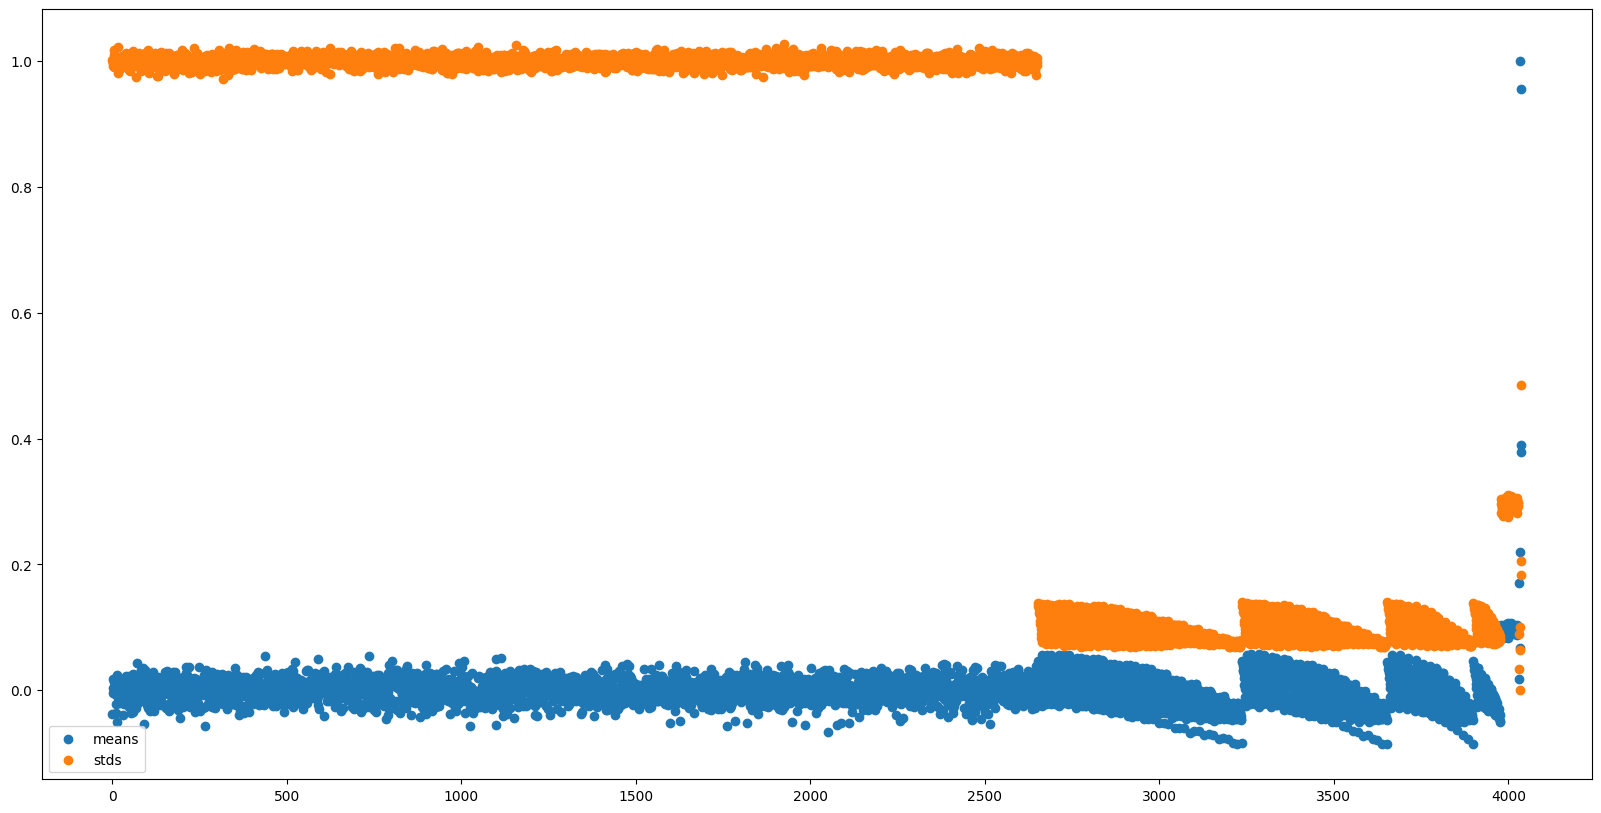

In [43]:
# Check that values are in correct range
fig, ax = plt.subplots(figsize=(20, 10))
plt.scatter(range(df.mean().size), df.mean(), label="means")
plt.scatter(range(df.std().size), df.std(), label="stds")
plt.legend()
plt.show()

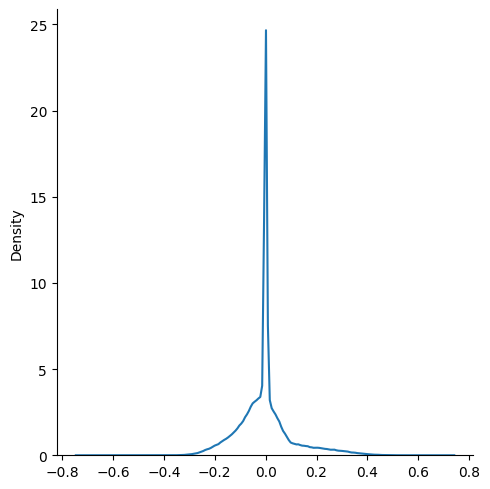

In [44]:
# Plot distribution of output values in a bell curve
from seaborn import displot

displot(raw_df[value_columns].to_numpy().flatten(), kind="kde")
plt.show()


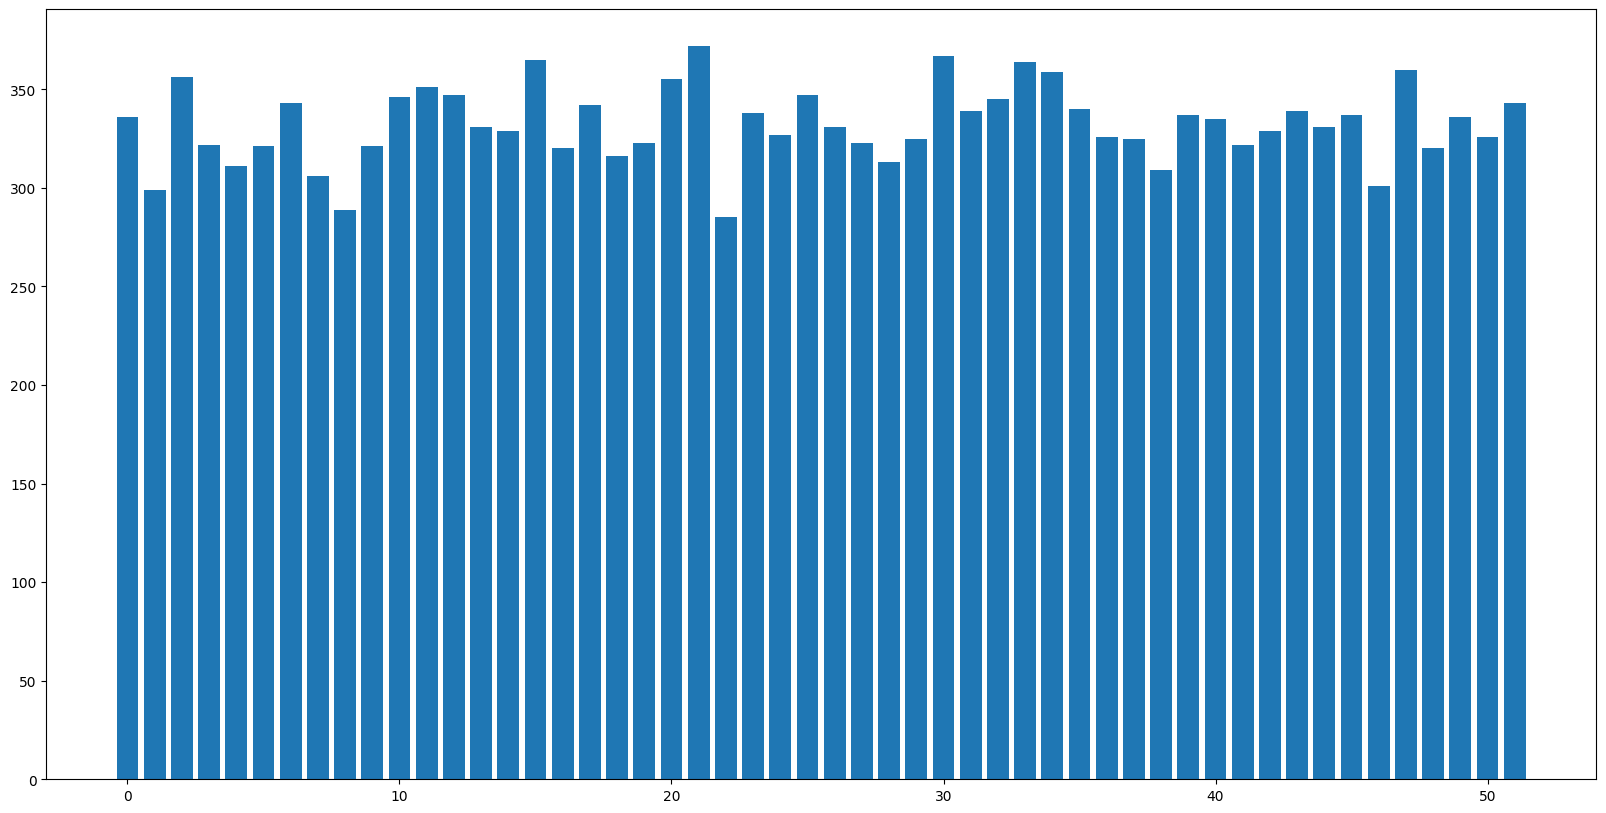

In [45]:
# Check representation of possible public cards
card_cols = [col for col in df.columns if col.startswith("public_card_")]
card_counts = df[card_cols].sum()
fig, ax = plt.subplots(figsize=(20, 10))
plt.bar(range(len(card_counts)), card_counts)
plt.show()

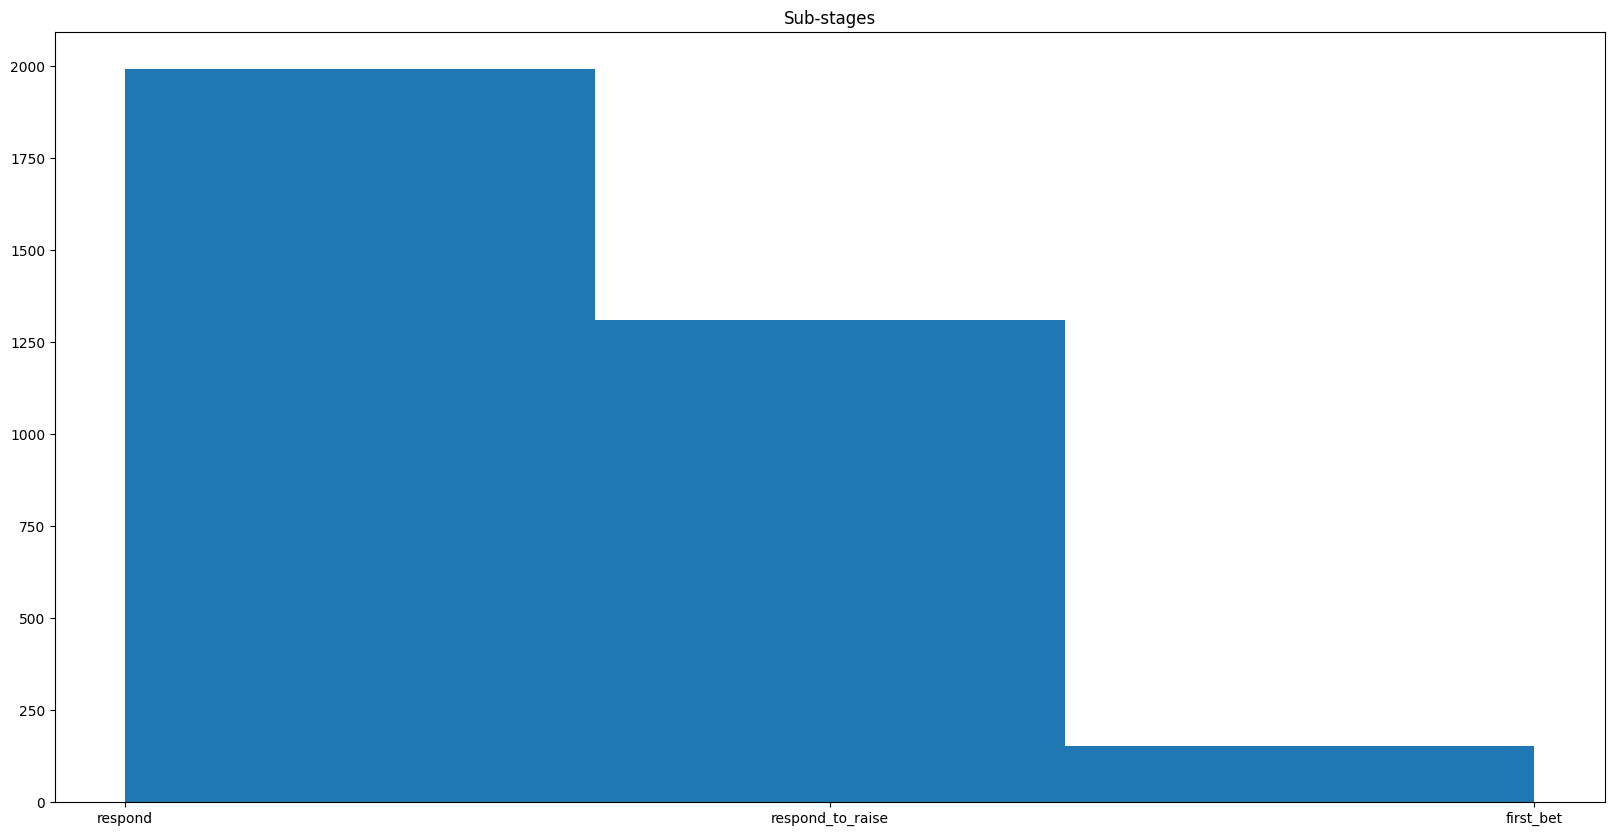

In [46]:
sub_stages = np.where(
    df["player_has_bet"] & df["opponent_has_bet"],
    "respond_to_raise",
    np.where(
        df["opponent_has_bet"],
        "respond",
        "first_bet"
    )
)
fig, ax = plt.subplots(figsize=(20, 10))
plt.hist(sub_stages, bins=3)
plt.title("Sub-stages")
plt.show()

In [47]:
Y_columns = [col for col in df.columns if col.startswith('value_of_hand_')]
X_columns = [col for col in df.columns if col not in Y_columns]
X = df[X_columns].values
Y = df[Y_columns].values
print(X.shape, Y.shape)

(3456, 2712) (3456, 1326)


### Structure for Neural Network

In [48]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [49]:
def generate_model():
    # Define input layer
    input_layer = Input(shape=(X.shape[1],), name="input_layer")

    # Define hidden layers
    hidden_layer_1 = Dense(128, activation="relu", name="hidden_layer_1")(input_layer)
    hidden_layer_2 = Dense(64, activation="relu", name="hidden_layer_2")(hidden_layer_1)
    hidden_layer_3 = Dense(32, activation="relu", name="hidden_layer_3")(hidden_layer_2)

    # Define value layer for player 1
    value_layer_P1 = Dense(Y.shape[1], activation="linear", name="value_layer_P1")(
        hidden_layer_3
    )

    model = Model(inputs=input_layer, outputs=value_layer_P1)
    model.compile(optimizer='adam', loss='mean_squared_error')

    return model

### Cross validation

In [50]:
# Split the data into training and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Set up K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# This will store the fold results
fold_results = []

# Define the early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',      # Monitor the validation loss
    patience=5,              # Number of epochs with no improvement after which training will be stopped
    verbose=1,               # To print the message when stopping
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity
)

# Loop over each fold
for i, (train_index, val_index) in enumerate(kf.split(X_train)):
    # Split the data into k-fold training and validation sets
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    Y_train_fold, Y_val_fold = Y_train[train_index], Y_train[val_index]

    print("@@@ FOLD", i+1, "@@@")
    print("Size of training set:", X_train_fold.shape[0])
    
    # Define and compile the neural network inside the loop to reset weights for each fold
    model = generate_model()
    
    # Train the model
    history = model.fit(
        X_train_fold, Y_train_fold,
        epochs=1000,
        validation_data=(X_val_fold, Y_val_fold),
        callbacks=[early_stopping]  # Include the early stopping callback here
    )
    
    # Save the history in fold_results
    fold_results.append(history.history)

@@@ FOLD 1 @@@
Size of training set: 2211
Epoch 1/1000
 8/70 [==>...........................] - ETA: 0s - loss: 0.1381 

2024-04-29 22:03:27.029375: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


70/70 [==============================] - 1s 11ms/step - loss: 0.0512 - val_loss: 0.0171
Epoch 2/1000
10/70 [===>..........................] - ETA: 0s - loss: 0.0152

2024-04-29 22:03:27.816980: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


70/70 [==============================] - 0s 7ms/step - loss: 0.0131 - val_loss: 0.0122
Epoch 3/1000
70/70 [==============================] - 1s 8ms/step - loss: 0.0110 - val_loss: 0.0113
Epoch 4/1000
70/70 [==============================] - 1s 8ms/step - loss: 0.0105 - val_loss: 0.0109
Epoch 5/1000
70/70 [==============================] - 0s 7ms/step - loss: 0.0103 - val_loss: 0.0108
Epoch 6/1000
70/70 [==============================] - 0s 7ms/step - loss: 0.0102 - val_loss: 0.0107
Epoch 7/1000
70/70 [==============================] - 0s 7ms/step - loss: 0.0101 - val_loss: 0.0107
Epoch 8/1000
70/70 [==============================] - 1s 7ms/step - loss: 0.0101 - val_loss: 0.0107
Epoch 9/1000
70/70 [==============================] - 0s 7ms/step - loss: 0.0101 - val_loss: 0.0108
Epoch 10/1000
70/70 [==============================] - 0s 7ms/step - loss: 0.0100 - val_loss: 0.0108
Epoch 11/1000
70/70 [==============================] - 1s 8ms/step - loss: 0.0100 - val_loss: 0.0109
Epoch 11: e

...

70/70 [==============================] - 1s 7ms/step - loss: 0.0134 - val_loss: 0.0120
Epoch 3/1000
70/70 [==============================] - 1s 8ms/step - loss: 0.0115 - val_loss: 0.0109
Epoch 4/1000
70/70 [==============================] - 0s 7ms/step - loss: 0.0109 - val_loss: 0.0105
Epoch 5/1000
70/70 [==============================] - 1s 8ms/step - loss: 0.0106 - val_loss: 0.0104
Epoch 6/1000
70/70 [==============================] - 1s 9ms/step - loss: 0.0104 - val_loss: 0.0105
Epoch 7/1000
70/70 [==============================] - 0s 7ms/step - loss: 0.0104 - val_loss: 0.0103
Epoch 8/1000
70/70 [==============================] - 0s 7ms/step - loss: 0.0105 - val_loss: 0.0102
Epoch 9/1000
70/70 [==============================] - 1s 8ms/step - loss: 0.0103 - val_loss: 0.0101
Epoch 10/1000
70/70 [==============================] - 1s 7ms/step - loss: 0.0102 - val_loss: 0.0102
Epoch 11/1000
70/70 [==============================] - 1s 7ms/step - loss: 0.0102 - val_loss: 0.0102
Epoch 12/10

2024-04-29 22:03:56.113779: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


70/70 [==============================] - 1s 9ms/step - loss: 0.0512 - val_loss: 0.0155
Epoch 2/1000
 9/70 [==>...........................] - ETA: 0s - loss: 0.0150

2024-04-29 22:03:56.735696: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


70/70 [==============================] - 1s 8ms/step - loss: 0.0132 - val_loss: 0.0112
Epoch 3/1000
70/70 [==============================] - 0s 7ms/step - loss: 0.0114 - val_loss: 0.0104
Epoch 4/1000
70/70 [==============================] - 0s 7ms/step - loss: 0.0109 - val_loss: 0.0100
Epoch 5/1000
70/70 [==============================] - 0s 7ms/step - loss: 0.0106 - val_loss: 0.0099
Epoch 6/1000
70/70 [==============================] - 1s 8ms/step - loss: 0.0105 - val_loss: 0.0099
Epoch 7/1000
70/70 [==============================] - 0s 7ms/step - loss: 0.0104 - val_loss: 0.0099
Epoch 8/1000
70/70 [==============================] - 0s 7ms/step - loss: 0.0104 - val_loss: 0.0099
Epoch 9/1000
70/70 [==============================] - 0s 7ms/step - loss: 0.0103 - val_loss: 0.0098
Epoch 10/1000
70/70 [==============================] - 1s 8ms/step - loss: 0.0103 - val_loss: 0.0100
Epoch 11/1000
70/70 [==============================] - 1s 8ms/step - loss: 0.0102 - val_loss: 0.0098
Epoch 12/10

In [51]:
mse_scores = []

# Evaluate each fold
for fold_history in fold_results:
    val_mse_per_epoch = fold_history['val_loss']
    mse_scores.append(val_mse_per_epoch[-1])  # Take the last epoch MSE

# Calculate the average and standard deviation of the MSE scores across all folds
average_mse = np.mean(mse_scores)
std_dev_mse = np.std(mse_scores)

print(f"Cross-Validation MSE: {average_mse:.4f} (+/- {std_dev_mse:.4f})")
rmse = np.sqrt(average_mse)
rmse_std_dev = np.sqrt(std_dev_mse)
print(f"Cross-Validation RMSE: {rmse:.4f} (+/- {rmse_std_dev:.4f})")

Cross-Validation MSE: 0.0106 (+/- 0.0004)
Cross-Validation RMSE: 0.1028 (+/- 0.0196)


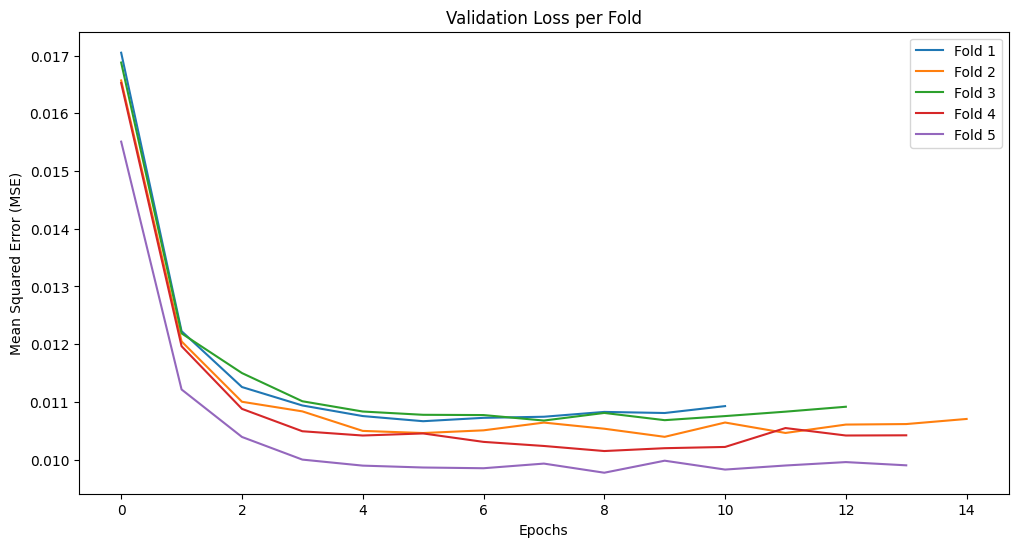

In [52]:
plt.figure(figsize=(12, 6))
for i, fold_history in enumerate(fold_results, 1):
    plt.plot(fold_history['val_loss'], label=f'Fold {i}')

plt.title('Validation Loss per Fold')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.show()

In [ ]:
# Find optimal number of epochs
optimal_epochs = []

for result in fold_results:
    val_loss_per_epoch = result['val_loss']
    best_epoch = val_loss_per_epoch.index(min(val_loss_per_epoch))
    optimal_epochs.append(best_epoch)

average_optimal_epoch = np.mean(optimal_epochs)
buffer = 5  # Add a small buffer to avoid underfitting
final_epoch_number = int(average_optimal_epoch + buffer)

print(f"Suggested number of epochs for final training: {final_epoch_number}")

### Testing

In [ ]:
# Test the model
model = generate_model()
model.fit(X_train, Y_train, epochs=final_epoch_number)
test_loss = model.evaluate(X_test, Y_test)
print(f"Test MSE: {test_loss:.4f}")
print(f"Test RMSE: {np.sqrt(test_loss):.4f}")

### Training of final model

In [ ]:
# Train model on all data
model = generate_model()
model.fit(X, Y, epochs=final_epoch_number)

# Change working directory to models
os.chdir("models")

# Save the model
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
model_fname = f"model_{stage}_{timestamp}.h5"
model.save(model_fname)

# Save metadata
metadata = {
    "mean_training_range_val": mean_training_range_val,
    "sd_training_range_val": sd_training_range_val,
}
meta_fname = f"model_{stage}_{timestamp}.json"
with open(meta_fname, "w") as f:
    json.dump(metadata, f)

# Symlink the model to the latest model
latest_fname = f"model_{stage}_latest.h5"
latest_meta_fname = f"model_{stage}_latest.json"
if os.path.exists(latest_fname):
    os.remove(latest_fname)
if os.path.exists(latest_meta_fname):
    os.remove(latest_meta_fname)
os.symlink(model_fname, latest_fname)
os.symlink(meta_fname, latest_meta_fname)

# Change working directory back to parent
os.chdir("..")

In [ ]:
# Test making a point prediction
X_test_point = X_test[0].reshape(1, -1)
Y_test_point = Y_test[0].reshape(1, -1)
print("X_test_point shape:", X_test_point.shape)
Y_pred_point = model.predict(X_test_point)
print("Test point prediction:")
print("Actual:", Y_test_point)
print("Predicted:", Y_pred_point)